In [ ]:
import pandas as pd

df = pd.read_csv('lung_cancer.csv')
df.head()

,age,gender,education_years,income_level,smoker,smoking_years,cigarettes_per_day,pack_years,passive_smoking,air_pollution_index,...,bmi,oxygen_saturation,fev1_x10,crp_level,xray_abnormal,exercise_hours_per_week,diet_quality,alcohol_units_per_week,healthcare_access,lung_cancer_risk
0,60,1,20,2,1,16,15,12,0,71,...,20,94,29,6,1,5,4,13,3,1
1,53,0,12,4,0,0,0,0,1,66,...,25,96,35,4,0,5,2,0,3,0
2,62,1,15,3,1,9,29,13,1,69,...,23,95,29,9,1,1,4,2,1,1
3,73,1,12,3,0,0,0,0,0,47,...,18,96,32,0,0,0,3,10,4,0
4,52,1,13,1,0,0,0,0,0,94,...,16,97,36,8,0,6,2,9,2,0


In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   age                      5000 non-null   int64
 1   gender                   5000 non-null   int64
 2   education_years          5000 non-null   int64
 3   income_level             5000 non-null   int64
 4   smoker                   5000 non-null   int64
 5   smoking_years            5000 non-null   int64
 6   cigarettes_per_day       5000 non-null   int64
 7   pack_years               5000 non-null   int64
 8   passive_smoking          5000 non-null   int64
 9   air_pollution_index      5000 non-null   int64
 10  occupational_exposure    5000 non-null   int64
 11  radon_exposure           5000 non-null   int64
 12  family_history_cancer    5000 non-null   int64
 13  copd                     5000 non-null   int64
 14  asthma                   5000 non-null   int64
 15  prev

,0
age,0
gender,0
education_years,0
income_level,0
smoker,0
smoking_years,0
cigarettes_per_day,0
pack_years,0
passive_smoking,0
air_pollution_index,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
import numpy as np


le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df['smoking_intensity'] = df['cigarettes_per_day'] * df['smoking_years']
df['risk_exposure'] = df['air_pollution_index'] * df['occupational_exposure']
df['health_risk'] = df['age'] * df['smoker']

df['symptom_score'] = (
    df['shortness_of_breath'] +
    df['chronic_cough'] +
    df['chest_pain']
)

df['log_pack_years'] = np.log1p(df['pack_years'])
df['age_squared'] = df['age'] ** 2

df['heavy_smoker'] = (df['cigarettes_per_day'] > 20).astype(int)
df['high_risk_job'] = (df['occupational_exposure'] > 0).astype(int)

In [ ]:
X = df.drop('lung_cancer_risk', axis=1)
y = df['lung_cancer_risk']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=10)

X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

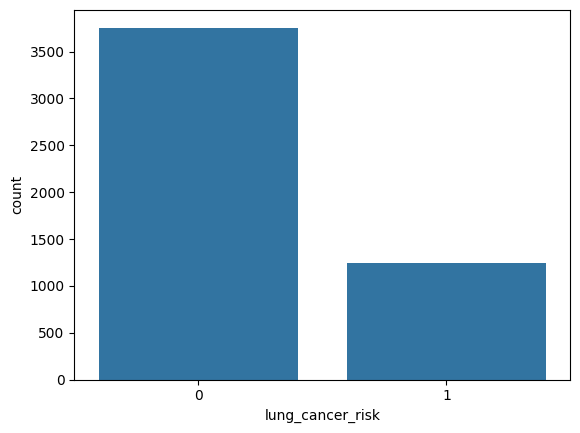

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=y)
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

model = LogisticRegression(max_iter=1000)

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Params: {'C': 10, 'solver': 'lbfgs'}
Best CV Score: 0.9010743005612074


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97       746
           1       0.90      0.91      0.90       254

    accuracy                           0.95      1000
   macro avg       0.93      0.94      0.93      1000
weighted avg       0.95      0.95      0.95      1000

Accuracy: 0.95


In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(eval_metric='logloss')

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression()
model1.fit(X_train_scaled, y_train)

y_pred1 = model1.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred1))
print(classification_report(y_test, y_pred1))


Accuracy: 0.954
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       746
           1       0.91      0.91      0.91       254

    accuracy                           0.95      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.95      0.95      0.95      1000



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

model2 = RandomForestClassifier()
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred2))
print(classification_report(y_test, y_pred2))


Accuracy: 0.941
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       746
           1       0.88      0.89      0.88       254

    accuracy                           0.94      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.94      0.94      0.94      1000



In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

model3 = SVC()
model3.fit(X_train_scaled, y_train)

y_pred3 = model3.predict(X_test_scaled)


print("Accuracy:", accuracy_score(y_test, y_pred3))
print(classification_report(y_test, y_pred3))


Accuracy: 0.951
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       746
           1       0.90      0.91      0.90       254

    accuracy                           0.95      1000
   macro avg       0.93      0.94      0.94      1000
weighted avg       0.95      0.95      0.95      1000

